In [226]:
!pip install kaggle

from google.colab import files
files.upload()  # upload kaggle.json


Saving kaggle.json to kaggle (4).json


{'kaggle (4).json': b'{"username":"achusn","key":"75a1c0701d1ea58d0d62b5edfa2c28e8"}'}

In [227]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/

In [228]:
!kaggle datasets download -d pranavraikokte/covid19-image-dataset

Dataset URL: https://www.kaggle.com/datasets/pranavraikokte/covid19-image-dataset
License(s): CC-BY-SA-4.0
covid19-image-dataset.zip: Skipping, found more recently modified local copy (use --force to force download)


In [229]:
import zipfile
zip_ref = zipfile.ZipFile('/content/covid19-image-dataset.zip', 'r')
zip_ref.extractall('/content')
zip_ref.close()

In [230]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras import Sequential
from keras.layers import Dense, Dropout, Flatten, Conv2D, MaxPooling2D,BatchNormalization

In [231]:
# generators

train_ds = keras.utils.image_dataset_from_directory(
    directory = '/content/Covid19-dataset/train',
    labels='inferred',
    label_mode = 'int',
    batch_size=32,
    image_size=(224,224)
)

test_ds = keras.utils.image_dataset_from_directory(
    directory = '/content/Covid19-dataset/test',
    labels='inferred',
    label_mode = 'int',
    batch_size=32,
    image_size=(224,224)
)

Found 251 files belonging to 3 classes.
Found 66 files belonging to 3 classes.


In [232]:
# Normalize

def process(image,label):
    image = tf.cast(image/224. ,tf.float32)
    return image,label

train_ds = train_ds.map(process)
test_ds = test_ds.map(process)

In [233]:
# create CNN model
from tensorflow.keras.layers import GlobalMaxPooling2D

model = Sequential()

model.add(Conv2D(32,kernel_size=(3,3),padding='valid',activation='relu',input_shape=(224,224,3)))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2),strides=2,padding='valid'))

model.add(Conv2D(64,kernel_size=(3,3),padding='valid',activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2),strides=2,padding='valid'))

model.add(Conv2D(128,kernel_size=(3,3),padding='valid',activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2),strides=2,padding='valid'))

model.add(GlobalMaxPooling2D())

model.add(Dense(128,activation='relu'))
model.add(Dropout(0.1))
model.add(Dense(64,activation='relu'))
model.add(Dropout(0.3))
model.add(Dense(3,activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [234]:
model.summary()

Model: "sequential_27"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_12 (Conv2D)              │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 222, 222, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 109, 109, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_14          │ (None, 52, 52, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling2d_12         │ (None, 128)            │             0 │
│ (GlobalMaxPooling2D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_38 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_25 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_39 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_26 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_40 (Dense)                │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 119,107 (465.26 KB)

 Trainable params: 118,659 (463.51 KB)

 Non-trainable params: 448 (1.75 KB)

In [235]:
model.compile(optimizer='adam',loss="sparse_categorical_crossentropy",metrics=['accuracy'])

In [236]:
# early stopping

from tensorflow.keras.callbacks import EarlyStopping

early_stopping = EarlyStopping(monitor='val_loss',patience=20,restore_best_weights=True)


In [237]:
history = model.fit(train_ds,
          epochs = 30,
          validation_data = test_ds,
          callbacks = early_stopping)

Epoch 1/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 14s 758ms/step - accuracy: 0.4022 - loss: 9.3820 - val_accuracy: 0.3182 - val_loss: 1.0970
Epoch 2/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 4s 549ms/step - accuracy: 0.4561 - loss: 1.9537 - val_accuracy: 0.3182 - val_loss: 1.0939
Epoch 3/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 4s 436ms/step - accuracy: 0.5804 - loss: 0.9603 - val_accuracy: 0.4091 - val_loss: 1.0879
Epoch 4/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 4s 533ms/step - accuracy: 0.6766 - loss: 0.8027 - val_accuracy: 0.3939 - val_loss: 1.0824
Epoch 5/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 9s 1s/step - accuracy: 0.7049 - loss: 0.6418 - val_accuracy: 0.3939 - val_loss: 1.0839
Epoch 6/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 9s 878ms/step - accuracy: 0.7769 - loss: 0.5081 - val_accuracy: 0.3939 - val_loss: 1.0864
Epoch 7/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 3s 373ms/step - accuracy: 0.8379 - loss: 0.4642 - val_accuracy: 0.3939 - val_loss: 1.0869
Epoch 8/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 3s 397ms/step - accuracy: 0.8401 - loss: 0.3979 - val_accuracy: 0.3939 - val_loss: 1

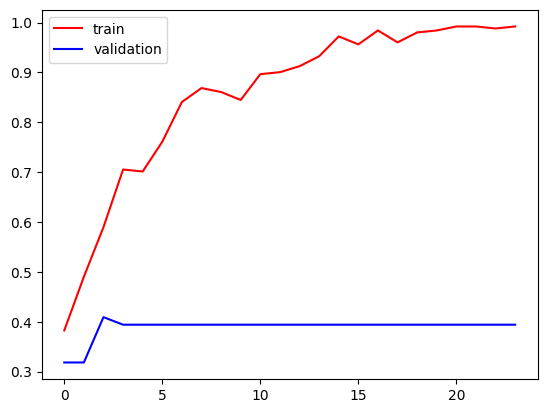

In [238]:

import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'],color='red',label='train')
plt.plot(history.history['val_accuracy'],color='blue',label='validation')
plt.legend()
plt.show()

In [239]:
history.history.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

In [240]:
loss, acc = model.evaluate(test_ds)
print("Loss:", loss)
print("Validation Accuracy:", acc)
print("train accuracy ,",history.history['accuracy'][-1])

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 164ms/step - accuracy: 0.4040 - loss: 1.0769
Loss: 1.0824384689331055
Validation Accuracy: 0.39393940567970276
train accuracy , 0.9920318722724915


## using VGG16

In [241]:
# generators
train_ds = keras.utils.image_dataset_from_directory(
    directory = '/content/Covid19-dataset/train',
    labels='inferred',
    label_mode = 'int',
    batch_size=32,
    image_size=(224,224)
)

validation_ds = keras.utils.image_dataset_from_directory(
    directory = '/content/Covid19-dataset/test',
    labels='inferred',
    label_mode = 'int',
    batch_size=32,
    image_size=(224,224)
)

Found 251 files belonging to 3 classes.
Found 66 files belonging to 3 classes.


In [242]:
from tensorflow.keras.applications.vgg16 import VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input


In [243]:
from tensorflow.keras.applications.vgg16 import preprocess_input

train_ds = train_ds.map(lambda x, y: (preprocess_input(x), y))
test_ds = test_ds.map(lambda x, y: (preprocess_input(x), y))

In [244]:
best_model = VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
best_model.trainable = False

In [245]:
model_vgg = Sequential()
model_vgg.add(best_model)
model_vgg.add(GlobalMaxPooling2D())

model_vgg.add(Dense(128,activation='relu'))
model_vgg.add(Dropout(0.1))
model_vgg.add(Dense(64,activation='relu'))
model_vgg.add(Dropout(0.3))
model_vgg.add(Dense(3,activation='softmax'))

In [246]:
model_vgg.summary()

Model: "sequential_28"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling2d_13         │ (None, 512)            │             0 │
│ (GlobalMaxPooling2D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_41 (Dense)                │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_27 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_42 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_28 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_43 (Dense)                │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,788,803 (56.41 MB)

 Trainable params: 74,115 (289.51 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [247]:
model_vgg.compile(optimizer='adam',loss="sparse_categorical_crossentropy",metrics=['accuracy'])

In [248]:
for images, labels in train_ds.take(1):
    print(images.shape)

(32, 224, 224, 3)


In [249]:
history_vgg = model_vgg.fit(train_ds,
          epochs = 30,
          validation_data = validation_ds)

Epoch 1/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 20s 1s/step - accuracy: 0.4461 - loss: 19.6892 - val_accuracy: 0.6818 - val_loss: 4.3561
Epoch 2/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 4s 474ms/step - accuracy: 0.6667 - loss: 7.5552 - val_accuracy: 0.6515 - val_loss: 6.3714
Epoch 3/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 5s 598ms/step - accuracy: 0.7444 - loss: 3.1174 - val_accuracy: 0.6818 - val_loss: 2.9025
Epoch 4/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 4s 482ms/step - accuracy: 0.7699 - loss: 2.2002 - val_accuracy: 0.7727 - val_loss: 1.7354
Epoch 5/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 4s 437ms/step - accuracy: 0.8509 - loss: 1.4225 - val_accuracy: 0.7424 - val_loss: 1.5983
Epoch 6/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 6s 561ms/step - accuracy: 0.8750 - loss: 0.9103 - val_accuracy: 0.7273 - val_loss: 1.5978
Epoch 7/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 4s 474ms/step - accuracy: 0.8494 - loss: 1.1063 - val_accuracy: 0.7727 - val_loss: 1.1747
Epoch 8/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 5s 477ms/step - accuracy: 0.8994 - loss: 0.7983 - val_accuracy: 0.7121 - val_loss: 

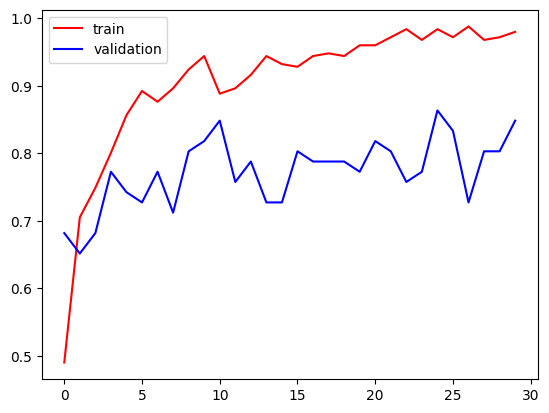

In [250]:
import matplotlib.pyplot as plt

plt.plot(history_vgg.history['accuracy'],color='red',label='train')
plt.plot(history_vgg.history['val_accuracy'],color='blue',label='validation')
plt.legend()
plt.show()

In [251]:
loss_vgg, acc_vgg = model_vgg.evaluate(validation_ds)
print("Loss:", loss_vgg)
print("Validation Accuracy:", acc_vgg)
print("train accuracy ,",history_vgg.history['accuracy'][-1])

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 138ms/step - accuracy: 0.8461 - loss: 0.6267
Loss: 0.6161952018737793
Validation Accuracy: 0.8484848737716675
train accuracy , 0.980079710483551


## Using ResNet50

In [252]:
# generators
train_ds = keras.utils.image_dataset_from_directory(
    directory = '/content/Covid19-dataset/train',
    labels='inferred',
    label_mode = 'int',
    batch_size=32,
    image_size=(224,224)
)

validation_ds = keras.utils.image_dataset_from_directory(
    directory = '/content/Covid19-dataset/test',
    labels='inferred',
    label_mode = 'int',
    batch_size=32,
    image_size=(224,224),shuffle = False
)

Found 251 files belonging to 3 classes.
Found 66 files belonging to 3 classes.


In [253]:
from tensorflow.keras.applications.resnet50 import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input

train_ds = train_ds.map(lambda x, y: (preprocess_input(x), y))
test_ds = test_ds.map(lambda x, y: (preprocess_input(x), y))

In [254]:
from tensorflow.keras.applications.resnet50 import ResNet50
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Sequential

base_model_resnet = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

base_model_resnet.trainable = False   # Freeze first


In [255]:
model_resnet = Sequential()
model_resnet.add(base_model_resnet)

model_resnet.add(GlobalMaxPooling2D())

model_resnet.add(Dense(128,activation='relu'))
model_resnet.add(Dropout(0.1))
model_resnet.add(Dense(64,activation='relu'))
model_resnet.add(Dropout(0.3))
model_resnet.add(Dense(3,activation='softmax'))

In [256]:
model_resnet.compile(optimizer='adam',loss="sparse_categorical_crossentropy",metrics=['accuracy'])

In [257]:
history_resnet = model_resnet.fit(train_ds,
          epochs = 30,
          validation_data = validation_ds)

Epoch 1/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 25s 2s/step - accuracy: 0.4006 - loss: 6.8055 - val_accuracy: 0.5606 - val_loss: 1.8175
Epoch 2/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 4s 436ms/step - accuracy: 0.6293 - loss: 1.9644 - val_accuracy: 0.6667 - val_loss: 1.4276
Epoch 3/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 5s 451ms/step - accuracy: 0.7396 - loss: 1.3278 - val_accuracy: 0.5909 - val_loss: 1.5883
Epoch 4/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 6s 605ms/step - accuracy: 0.8136 - loss: 0.6028 - val_accuracy: 0.6364 - val_loss: 1.0757
Epoch 5/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 4s 435ms/step - accuracy: 0.8735 - loss: 0.4105 - val_accuracy: 0.6667 - val_loss: 0.7505
Epoch 6/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 4s 475ms/step - accuracy: 0.9549 - loss: 0.1330 - val_accuracy: 0.8030 - val_loss: 0.4366
Epoch 7/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 5s 608ms/step - accuracy: 0.9520 - loss: 0.1258 - val_accuracy: 0.6515 - val_loss: 1.2206
Epoch 8/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 4s 441ms/step - accuracy: 0.9227 - loss: 0.1997 - val_accuracy: 0.7727 - val_loss: 0

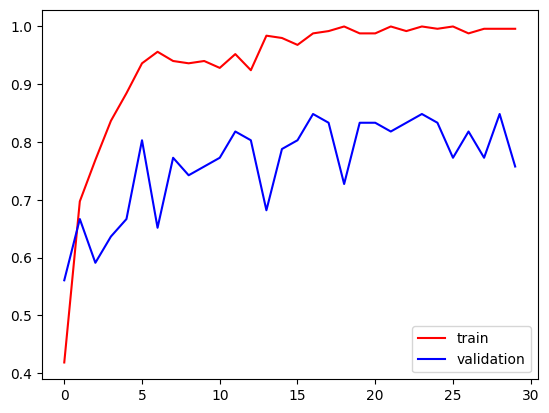

In [258]:
import matplotlib.pyplot as plt

plt.plot(history_resnet.history['accuracy'],color='red',label='train')
plt.plot(history_resnet.history['val_accuracy'],color='blue',label='validation')
plt.legend()
plt.show()

In [259]:
loss_resnet, acc_resnet = model_resnet.evaluate(validation_ds)
print("Loss:", loss_resnet)
print("Validation Accuracy:", acc_resnet)
print("train accuracy ,",history_resnet.history['accuracy'][-1])

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 157ms/step - accuracy: 0.7694 - loss: 1.1973
Loss: 1.2758866548538208
Validation Accuracy: 0.7575757503509521
train accuracy , 0.9960159659385681


## Using Data Augmentation

In [260]:
from tensorflow.keras import layers

data_augmentation = Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomContrast(0.1),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)
])

In [261]:
from tensorflow.keras.applications.resnet50 import ResNet50
from tensorflow.keras.layers import GlobalMaxPooling2D,Dense,Dropout
from tensorflow.keras.models import Sequential


base_model_resnet = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

base_model_resnet.trainable = False

In [262]:

model_resnet_aug = Sequential()

model_resnet_aug.add(data_augmentation)

model_resnet_aug.add(layers.Lambda(preprocess_input))

model_resnet_aug.add(base_model_resnet)


model_resnet_aug.add(GlobalMaxPooling2D())

model_resnet_aug.add(Dense(128,activation='relu'))
model_resnet_aug.add(Dropout(0.1))
model_resnet_aug.add(Dense(64,activation='relu'))
model_resnet_aug.add(Dropout(0.3))
model_resnet_aug.add(Dense(3,activation='softmax'))

In [263]:
model_resnet_aug.compile(optimizer='adam',loss="sparse_categorical_crossentropy",metrics=['accuracy'])

In [264]:
history_resnet_aug = model_resnet_aug.fit(train_ds,
          epochs = 30,
          validation_data = validation_ds)

Epoch 1/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 13s 852ms/step - accuracy: 0.4667 - loss: 4.8542 - val_accuracy: 0.5000 - val_loss: 2.1079
Epoch 2/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 4s 460ms/step - accuracy: 0.5615 - loss: 2.3566 - val_accuracy: 0.6212 - val_loss: 1.1029
Epoch 3/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 4s 432ms/step - accuracy: 0.6790 - loss: 1.2934 - val_accuracy: 0.5606 - val_loss: 1.1055
Epoch 4/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 5s 614ms/step - accuracy: 0.7787 - loss: 0.7049 - val_accuracy: 0.4848 - val_loss: 1.4935
Epoch 5/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 4s 463ms/step - accuracy: 0.7812 - loss: 0.6304 - val_accuracy: 0.5909 - val_loss: 1.3207
Epoch 6/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 4s 450ms/step - accuracy: 0.8031 - loss: 0.6236 - val_accuracy: 0.5152 - val_loss: 1.3673
Epoch 7/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 5s 603ms/step - accuracy: 0.8046 - loss: 0.5938 - val_accuracy: 0.5909 - val_loss: 0.9044
Epoch 8/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 4s 461ms/step - accuracy: 0.8059 - loss: 0.5842 - val_accuracy: 0.6818 - val_loss

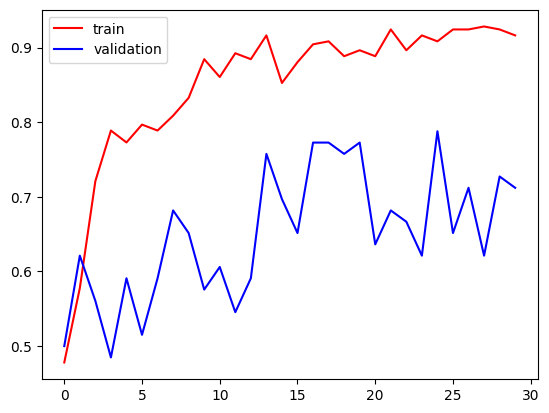

In [265]:
import matplotlib.pyplot as plt

plt.plot(history_resnet_aug.history['accuracy'],color='red',label='train')
plt.plot(history_resnet_aug.history['val_accuracy'],color='blue',label='validation')
plt.legend()
plt.show()

In [266]:
loss_resnet_aug, acc_resnet_aug = model_resnet_aug.evaluate(validation_ds)
print("Loss:", loss_resnet_aug)
print("Validation Accuracy:", acc_resnet_aug)
print("train accuracy ,",history_resnet_aug.history['accuracy'][-1])

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 112ms/step - accuracy: 0.6959 - loss: 0.8008
Loss: 0.7233023047447205
Validation Accuracy: 0.7121211886405945
train accuracy , 0.9163346886634827


In [284]:
import pandas as pd

comparison = pd.DataFrame({
    "Model": ["VGG16", "ResNet50", "ResNet50 + Augmentation"],
    "Train Accuracy": [
        history_vgg.history['accuracy'][-1],
        history_resnet.history['accuracy'][-1],
        history_resnet_aug.history['accuracy'][-1]
    ],
    "Validation Accuracy": [
        acc_vgg,
        acc_resnet,
        acc_resnet_aug
    ]
})

comparison.sort_values(by="Validation Accuracy",ascending=False).reset_index(drop=True)

,Model,Train Accuracy,Validation Accuracy
0,VGG16,0.980080,0.848485
1,ResNet50,0.996016,0.757576
2,ResNet50 + Augmentation,0.916335,0.712121


In [275]:
import numpy as np

# Get predictions
predictions = model_vgg.predict(validation_ds)

# Convert probabilities to class index
predicted_classes = np.argmax(predictions, axis=1)

predicted_classes[:10]

2/3 ━━━━━━━━━━━━━━━━━━━━ 0s 176ms/step

3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 394ms/step


array([0, 0, 0, 0, 0, 0, 0, 0, 0, 2])

In [276]:
true_labels = np.concatenate([y for x, y in validation_ds], axis=0)

true_labels[:10]

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0], dtype=int32)

In [277]:
from sklearn.metrics import accuracy_score

accuracy_score(true_labels, predicted_classes)

0.8484848484848485

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step


(np.float64(-0.5), np.float64(223.5), np.float64(223.5), np.float64(-0.5))

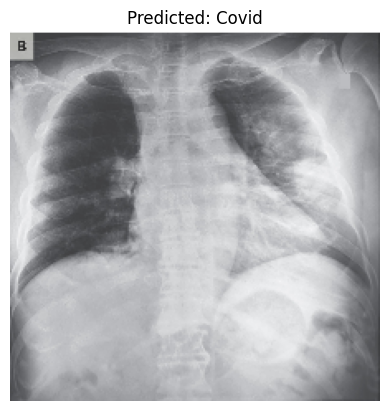

In [282]:
import tensorflow as tf
import matplotlib.pyplot as plt

class_names = validation_ds.class_names

img_path = "/content/Covid19-dataset/test/Covid/auntminnie-b-2020_01_28_23_51_6665_2020_01_28_Vietnam_coronavirus.jpeg"

img = tf.keras.preprocessing.image.load_img(img_path, target_size=(224,224))
img_array = tf.keras.preprocessing.image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)

prediction = model_resnet.predict(img_array)
predicted_class = class_names[np.argmax(prediction)]

plt.imshow(img)
plt.title(f"Predicted: {predicted_class}")
plt.axis("off")